# Embedding Quality Exploration

 

Inspect ArcFace embedding quality for a small, configurable subset of identities before introducing quantization noise. This notebook focuses on:

- Collecting embeddings with the existing detector/alignment stack

- Measuring intra- vs inter-identity cosine similarities

- Gauging centroid separation and nearest-neighbor re-id accuracy

- Visualizing clusters via PCA to spot overlapping identities


## Workflow

1. Configure the subset of identities / sampling budget.
2. Run the detector + aligner + embedder to collect embeddings.
3. Inspect cosine-similarity statistics, centroid separation, and PCA plots.
4. Decide whether the raw embeddings are sufficient for re-identification.

In [1]:
from __future__ import annotations

import copy
import pickle
import sys
from collections import Counter, defaultdict
from pathlib import Path
from typing import Dict, Iterable, List, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-darkgrid")

PROJECT_ROOT = Path("..").resolve()
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.append(str(SRC_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\tfrva\OneDrive\Documenten\CSE Master\Master Thesis\Repositories\msc-thesis-utility-preserving-video-anonymization\code


In [2]:
CONFIG_PATH = PROJECT_ROOT / "config/exp01_quantization.yaml"
IDENTITY_WHITELIST = []  # e.g., ["0", "1", "2"] to force a manual subset
MAX_IDENTITIES = 5
MAX_IMAGES_PER_ID = 20
MAX_TOTAL_SAMPLES = 200
MIN_IMAGES_PER_ID = 5
BETWEEN_PAIR_SAMPLES = 5000
MAX_POINTS_FOR_PCA = 400
RANDOM_SEED = 13
USE_CACHE = True
CACHE_PATH = PROJECT_ROOT / ".cache" / "embedding_analysis" / "celeba_subset.pkl"
CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)

print("Configuration ready → adjust the cell above to target a manageable subset of identities.")

Configuration ready → adjust the cell above to target a manageable subset of identities.


In [3]:
from anon_pipeline.utils.config_loader import load_config
from anon_pipeline.data import iter_samples
from anon_pipeline.data.io import load_image
from anon_pipeline.components import ArcFaceEmbedder, RetinaFaceDetector
from anon_pipeline.utils.alignment import FivePointAffineAligner

def auto_select_identities(exp_cfg, limit, min_images):
    dataset_type = exp_cfg.data.dataset_type.lower()
    counts = Counter()
    if dataset_type != "celeba":
        return [], counts
    options = exp_cfg.data.options or {}
    identity_file = exp_cfg.data.dataset_path / options.get("identity_file", "identity_CElebA.txt")
    if not identity_file.exists():
        raise FileNotFoundError(f"Missing identity mapping file: {identity_file}")
    with identity_file.open("r", encoding="utf-8") as handle:
        for line in handle:
            stripped = line.strip()
            if not stripped:
                continue
            _, identity = stripped.split()
            counts[identity] += 1
    ranked = [identity for identity, count in counts.most_common() if count >= min_images]
    return ranked[:limit], counts

def make_data_config_for_subset(base_cfg, identities, max_per_identity, max_samples):
    cfg = copy.deepcopy(base_cfg)
    cfg.options = dict(cfg.options or {})
    if identities:
        cfg.options["identities"] = [str(identity) for identity in identities]
    if max_per_identity:
        cfg.options["max_per_identity"] = int(max_per_identity)
    if max_samples:
        cfg.options["max_samples"] = int(max_samples)
    return cfg

def gather_samples(data_cfg):
    samples = list(iter_samples(data_cfg))
    identity_counts = Counter(sample.identity for sample in samples)
    print(f"Selected {len(identity_counts)} identities / {len(samples)} samples for analysis.")
    return samples, identity_counts

def build_models(exp_cfg):
    det_cfg = exp_cfg.detector
    detector = RetinaFaceDetector(
        model_name=det_cfg.name,
        score_threshold=det_cfg.score_threshold,
        det_size=tuple(det_cfg.det_size),
        max_faces=det_cfg.max_faces,
        ctx_id=det_cfg.ctx_id,
        providers=det_cfg.providers,
        root=str(det_cfg.root) if det_cfg.root else None,
    )
    aligner = FivePointAffineAligner(output_size=112)
    emb_cfg = exp_cfg.embedding
    embedder = ArcFaceEmbedder(
        model_name=emb_cfg.name,
        ctx_id=emb_cfg.ctx_id,
        providers=emb_cfg.providers,
        root=str(emb_cfg.root) if emb_cfg.root else None,
    )
    return detector, aligner, embedder

def normalize_embeddings(array):
    if array.size == 0:
        return array
    norms = np.linalg.norm(array, axis=1, keepdims=True)
    norms = np.clip(norms, 1e-8, None)
    return array / norms

def gather_within_similarity_values(embeddings_by_id):
    sims_by_id = {}
    for identity, vectors in embeddings_by_id.items():
        if vectors.shape[0] < 2:
            continue
        normalized = normalize_embeddings(vectors)
        matrix = normalized @ normalized.T
        tri = matrix[np.triu_indices(matrix.shape[0], k=1)]
        sims_by_id[identity] = tri
    return sims_by_id

def compute_within_identity_stats(sims_by_id):
    rows = []
    for identity, sims in sims_by_id.items():
        if sims.size == 0:
            continue
        rows.append(
            {
                "identity": identity,
                "pairs": int(sims.size),
                "mean_cos": float(np.mean(sims)),
                "median_cos": float(np.median(sims)),
                "min_cos": float(np.min(sims)),
                "max_cos": float(np.max(sims)),
            }
        )
    return pd.DataFrame(rows).sort_values("mean_cos", ascending=False) if rows else pd.DataFrame()

def sample_between_identity_pairs(embeddings_by_id, max_pairs, seed):
    usable = [
        (identity, normalize_embeddings(vectors))
        for identity, vectors in embeddings_by_id.items()
        if vectors.size > 0
    ]
    if len(usable) < 2 or max_pairs <= 0:
        return np.array([]), []
    rng = np.random.default_rng(seed)
    sims = []
    labels = []
    while len(sims) < max_pairs:
        idx_a, idx_b = rng.choice(len(usable), size=2, replace=False)
        id_a, vecs_a = usable[idx_a]
        id_b, vecs_b = usable[idx_b]
        vec_a = vecs_a[rng.integers(0, vecs_a.shape[0])]
        vec_b = vecs_b[rng.integers(0, vecs_b.shape[0])]
        sims.append(float(np.dot(vec_a, vec_b)))
        labels.append((id_a, id_b))
    return np.asarray(sims, dtype=np.float32), labels

def evaluate_top1_accuracy(embeddings_by_id):
    all_vectors = []
    labels = []
    for identity, vectors in embeddings_by_id.items():
        if vectors.size == 0:
            continue
        for vector in vectors:
            all_vectors.append(vector)
            labels.append(identity)
    if len(all_vectors) < 2:
        return None
    normalized = normalize_embeddings(np.vstack(all_vectors))
    sims = normalized @ normalized.T
    np.fill_diagonal(sims, -1.0)
    nearest = sims.argmax(axis=1)
    correct = sum(1 for idx, nbr in enumerate(nearest) if labels[idx] == labels[nbr])
    return correct / len(labels)

def summarize_centroid_separation(embeddings_by_id):
    centroids = []
    identities = []
    counts = []
    for identity, vectors in embeddings_by_id.items():
        if vectors.size == 0:
            continue
        normalized = normalize_embeddings(vectors)
        centroid = normalized.mean(axis=0)
        norm = np.linalg.norm(centroid)
        if norm == 0:
            continue
        centroid /= norm
        centroids.append(centroid)
        identities.append(identity)
        counts.append(normalized.shape[0])
    if not centroids:
        return None
    centroid_matrix = np.vstack(centroids)
    sims = centroid_matrix @ centroid_matrix.T
    mask = ~np.eye(len(identities), dtype=bool)
    off_diag = sims[mask]
    summary = pd.DataFrame(
        {
            "identity": identities,
            "samples": counts,
            "centroid_norm": np.linalg.norm(centroid_matrix, axis=1),
        }
    ).sort_values("samples", ascending=False)
    return {
        "summary": summary,
        "similarity_matrix": sims,
        "min_similarity": float(off_diag.min()) if off_diag.size else float("nan"),
        "median_similarity": float(np.median(off_diag)) if off_diag.size else float("nan"),
    }

def sample_embeddings_for_plot(embeddings_by_id, max_points, seed):
    rng = np.random.default_rng(seed)
    per_identity_cap = max(1, max_points // max(1, len(embeddings_by_id)))
    samples = []
    for identity, vectors in embeddings_by_id.items():
        if vectors.size == 0:
            continue
        normalized = normalize_embeddings(vectors)
        count = min(per_identity_cap, normalized.shape[0])
        if count == 0:
            continue
        indices = rng.choice(normalized.shape[0], size=count, replace=False)
        for idx in indices:
            samples.append((identity, normalized[idx]))
    if not samples:
        return None
    labels, vectors = zip(*samples)
    matrix = np.vstack(vectors)
    projection = project_pca(matrix, n_components=2)
    return pd.DataFrame({"identity": labels, "pc1": projection[:, 0], "pc2": projection[:, 1]})

def project_pca(array, n_components=2):
    centered = array - array.mean(axis=0, keepdims=True)
    u, s, vt = np.linalg.svd(centered, full_matrices=False)
    components = vt[:n_components]
    return centered @ components.T

def harvest_embeddings(samples, detector, aligner, embedder):
    embeddings_by_id = defaultdict(list)
    records = []
    failures = []
    for idx, sample in enumerate(samples, start=1):
        image = load_image(sample.path)
        detections = detector.detect(image)
        if not detections:
            failures.append({"identity": sample.identity, "file": sample.path.name, "reason": "no_detections"})
            continue
        aligned = [aligner.align(image, det) for det in detections]
        embeddings = embedder.embed(aligned)
        if embeddings.size == 0:
            failures.append({"identity": sample.identity, "file": sample.path.name, "reason": "empty_embeddings"})
            continue
        for det, emb in zip(detections, embeddings):
            embeddings_by_id[sample.identity].append(emb)
            records.append(
                {
                    "identity": sample.identity,
                    "file_name": sample.path.name,
                    "det_score": float(getattr(det, "score", 0.0)),
                    "embedding_norm": float(np.linalg.norm(emb)),
                }
            )
        if idx % 25 == 0:
            print(f"Processed {idx} / {len(samples)} samples...")
    stacked = {identity: np.vstack(vectors) for identity, vectors in embeddings_by_id.items()}
    record_df = pd.DataFrame.from_records(records)
    return stacked, record_df, failures

In [4]:
exp_config = load_config(CONFIG_PATH)
print(f"Loaded experiment config from {CONFIG_PATH}")

if IDENTITY_WHITELIST:
    target_identities = [str(identity) for identity in IDENTITY_WHITELIST]
    identity_counts = Counter({identity: None for identity in target_identities})
else:
    target_identities, identity_counts = auto_select_identities(
        exp_config,
        limit=MAX_IDENTITIES,
        min_images=MIN_IMAGES_PER_ID,
    )
    if not target_identities:
        raise ValueError(
            "No identities satisfied the selection criteria. Set IDENTITY_WHITELIST manually."
        )

print(f"Target identities: {target_identities}")
analysis_data_cfg = make_data_config_for_subset(
    exp_config.data,
    identities=target_identities,
    max_per_identity=MAX_IMAGES_PER_ID,
    max_samples=MAX_TOTAL_SAMPLES,
)
samples, sample_identity_counts = gather_samples(analysis_data_cfg)
if sample_identity_counts:
    sample_table = pd.DataFrame.from_records(
        [
            {"identity": identity, "images": count}
            for identity, count in sample_identity_counts.most_common()
        ]
    )
    display(sample_table)
else:
    print("No samples selected. Adjust the filters above.")

Loaded experiment config from C:\Users\tfrva\OneDrive\Documenten\CSE Master\Master Thesis\Repositories\msc-thesis-utility-preserving-video-anonymization\code\config\exp01_quantization.yaml
Target identities: ['2820', '3782', '3227', '3745', '3699']
Selected 5 identities / 100 samples for analysis.


,identity,images
0,2820,20
1,3745,20
2,3699,20
3,3782,20
4,3227,20


In [5]:
detector, aligner, embedder = build_models(exp_config)
print("Detector model:", detector.model_name)
print("Embedder model:", embedder.model_name)

Detector model: buffalo_l
Embedder model: arcface_r100_v1


In [6]:
if USE_CACHE and CACHE_PATH.exists():
    with CACHE_PATH.open("rb") as handle:
        cache_payload = pickle.load(handle)
    embeddings_by_id = {k: v for k, v in cache_payload["embeddings"].items()}
    record_df = cache_payload["records"]
    failure_log = cache_payload["failures"]
    print(f"Loaded {sum(arr.shape[0] for arr in embeddings_by_id.values())} embeddings from cache.")
else:
    embeddings_by_id, record_df, failure_log = harvest_embeddings(samples, detector, aligner, embedder)
    if USE_CACHE:
        with CACHE_PATH.open("wb") as handle:
            pickle.dump(
                {
                    "embeddings": embeddings_by_id,
                    "records": record_df,
                    "failures": failure_log,
                },
                handle,
            )
        print(f"Cached embeddings → {CACHE_PATH}")

Loaded 99 embeddings from cache.


In [7]:
total_embeddings = sum(arr.shape[0] for arr in embeddings_by_id.values())
print(f"Collected {total_embeddings} embeddings across {len(embeddings_by_id)} identities.")
if not record_df.empty:
    summary = (
        record_df.groupby("identity")
        .agg(
            embeddings=("embedding_norm", "size"),
            mean_norm=("embedding_norm", "mean"),
            std_norm=("embedding_norm", "std"),
            mean_det_score=("det_score", "mean"),
        )
        .sort_values("embeddings", ascending=False)
    )
    display(summary)
else:
    print("No embedding records available.")
if failure_log:
    failure_df = pd.DataFrame(failure_log)
    display(failure_df["reason"].value_counts().rename_axis("failure").to_frame("count"))
else:
    print("No detector / embedder failures recorded.")

Collected 99 embeddings across 5 identities.


,embeddings,mean_norm,std_norm,mean_det_score
identity,,,,
3782,21,1.0,4.050945e-08,0.804774
2820,20,1.0,2.916816e-08,0.841067
3227,20,1.0,2.802386e-08,0.822491
3745,20,1.0,3.404859e-08,0.821726
3699,18,1.0,2.549843e-08,0.815962


,count
failure,
no_detections,2


In [8]:
within_values = gather_within_similarity_values(embeddings_by_id)
within_stats_df = compute_within_identity_stats(within_values)
if not within_stats_df.empty:
    display(within_stats_df)
    all_within = np.concatenate(list(within_values.values()))
    print(
        f"Overall same-identity cosine: mean={all_within.mean():.4f}, std={all_within.std():.4f} (pairs={all_within.size})"
    )
else:
    all_within = np.array([])
    print("Not enough embeddings per identity to compute intra-class similarities.")

,identity,pairs,mean_cos,median_cos,min_cos,max_cos
4,3227,190,0.648579,0.655375,0.422534,0.846167
0,2820,190,0.620337,0.609082,0.490417,0.961042
2,3699,153,0.572604,0.576080,0.289511,0.911671
1,3745,190,0.515338,0.507100,0.312786,0.776977
3,3782,210,0.412735,0.438913,-0.104839,0.704679


Overall same-identity cosine: mean=0.5502, std=0.1410 (pairs=933)


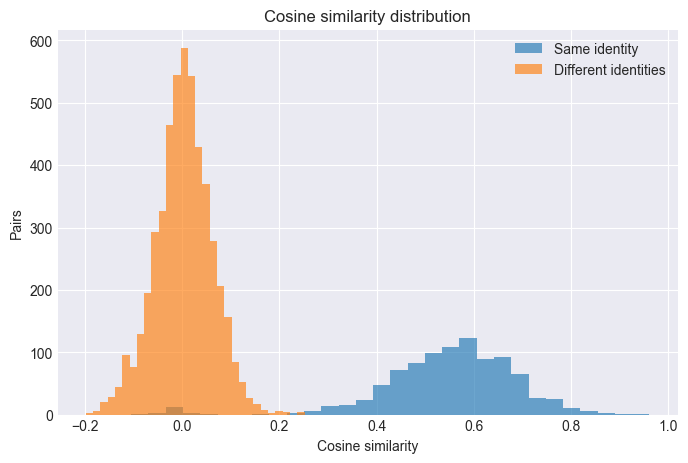

Mean same-id cosine=0.5502 vs diff-id=0.0033; Δ=0.5468


In [9]:
between_sims, between_pairs = sample_between_identity_pairs(
    embeddings_by_id,
    max_pairs=BETWEEN_PAIR_SAMPLES,
    seed=RANDOM_SEED,
)
if between_sims.size > 0 and all_within.size > 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(all_within, bins=30, alpha=0.65, label="Same identity")
    ax.hist(between_sims, bins=30, alpha=0.65, label="Different identities")
    ax.set_xlabel("Cosine similarity")
    ax.set_ylabel("Pairs")
    ax.set_title("Cosine similarity distribution")
    ax.legend()
    plt.show()
    print(
        f"Mean same-id cosine={all_within.mean():.4f} vs diff-id={between_sims.mean():.4f}; "
        f"Δ={all_within.mean() - between_sims.mean():.4f}"
    )
elif all_within.size == 0:
    print("No same-identity pairs available.")
else:
    print("Not enough identities to sample cross-identity similarities.")

In [10]:
top1 = evaluate_top1_accuracy(embeddings_by_id)
if top1 is None:
    print("Not enough embeddings to run nearest-neighbor evaluation.")
else:
    print(f"Nearest-neighbor re-id accuracy (cosine, leave-one-out): {top1:.3%}")
centroid_report = summarize_centroid_separation(embeddings_by_id)
if centroid_report:
    display(centroid_report["summary"])
    print(
        f"Centroid cosine similarity: min={centroid_report['min_similarity']:.4f}, "
        f"median={centroid_report['median_similarity']:.4f}"
    )
else:
    print("Centroid analysis unavailable (insufficient embeddings).")

Nearest-neighbor re-id accuracy (cosine, leave-one-out): 98.990%


,identity,samples,centroid_norm
3,3782,21,1.0
0,2820,20,1.0
1,3745,20,1.0
4,3227,20,1.0
2,3699,18,1.0


Centroid cosine similarity: min=-0.1203, median=0.0030


C:\Users\tfrva\AppData\Local\Temp\ipykernel_30156\3803069259.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20")


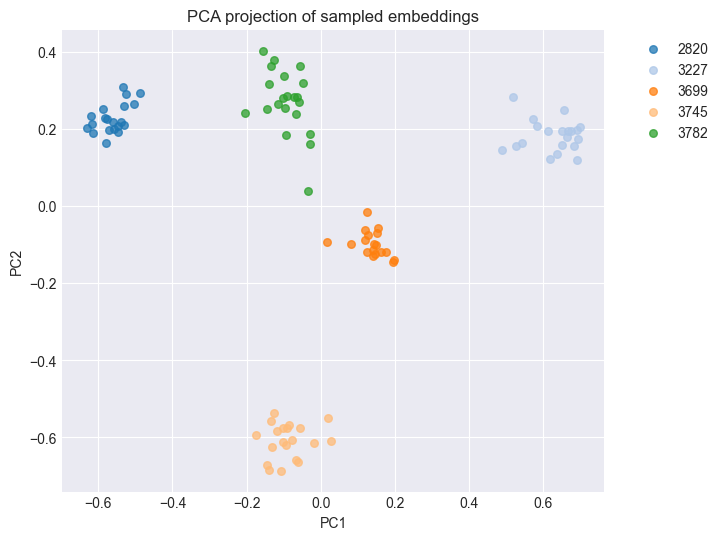

In [11]:
projection_df = sample_embeddings_for_plot(embeddings_by_id, MAX_POINTS_FOR_PCA, RANDOM_SEED)
if projection_df is None:
    print("Not enough embeddings for PCA visualization.")
else:
    fig, ax = plt.subplots(figsize=(7, 6))
    cmap = plt.cm.get_cmap("tab20")
    for idx, (identity, group) in enumerate(projection_df.groupby("identity")):
        ax.scatter(
            group["pc1"],
            group["pc2"],
            label=identity,
            alpha=0.75,
            s=30,
            color=cmap(idx % cmap.N),
        )
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title("PCA projection of sampled embeddings")
    ax.legend(bbox_to_anchor=(1.04, 1), loc="upper left", ncol=1)
    plt.show()